# 03 - Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned stock market dataset and understand the historical behavior of Apple's stock through statistical summaries and visualizations.

The dataset is continuously updated with newly available market data collected from Yahoo Finance.

### Analysis Performed

- Dataset Overview
- Statistical Summary
- Closing Price Trend
- Trading Volume Trend
- Price Distribution
- Outlier Detection
- Correlation Analysis
- Pair Plot Analysis

In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# all plots shown inside of the notebook
%matplotlib inline  

In [14]:
apple = pd.read_csv(
    "../data/cleaned/AAPL.csv",
    parse_dates=["Date"]
)

apple.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Company
0,2015-01-02,24.171762,27.332500,27.860001,26.837500,27.847500,212818400,AAPL
1,2015-01-05,23.490801,26.562500,27.162500,26.352501,27.072500,257142000,AAPL
2,2015-01-06,23.493010,26.565001,26.857500,26.157499,26.635000,263188400,AAPL
3,2015-01-07,23.822430,26.937500,27.049999,26.674999,26.799999,160423600,AAPL
4,2015-01-08,24.737745,27.972500,28.037500,27.174999,27.307501,237458000,AAPL


In [15]:
print("Shape :", apple.shape)

Shape : (2945, 8)


In [16]:
apple.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2945 entries, 0 to 2944
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2945 non-null   datetime64[ns]
 1   Adj Close  2945 non-null   float64       
 2   Close      2945 non-null   float64       
 3   High       2945 non-null   float64       
 4   Low        2945 non-null   float64       
 5   Open       2945 non-null   float64       
 6   Volume     2945 non-null   int64         
 7   Company    2945 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 184.2+ KB


In [17]:
apple.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,2945,2020-11-07 17:15:08.251273472,2015-01-02 00:00:00,2017-12-04 00:00:00,2020-11-05 00:00:00,2023-10-11 00:00:00,2026-09-18 00:00:00,NaN
Adj Close,2945.0,117.047366,20.548145,37.679626,115.904991,176.463318,339.786926,84.137782
Close,2945.0,119.519348,22.584999,40.400002,119.389999,179.289993,340.079987,83.640391
High,2945.0,120.713434,22.9175,40.93,120.989998,180.589996,344.570007,84.462623
Low,2945.0,118.204454,22.3675,40.0,118.0,177.339996,337.350006,82.71363
Open,2945.0,119.403058,22.5,40.487499,119.550003,179.279999,340.029999,83.529435
Volume,2945.0,107662683.870968,17910600.0,59907000.0,90370200.0,133838400.0,648825200.0,67787261.392274


## Observation

- The dataset contains daily historical stock prices.
- There are no missing values.
- Numerical columns are ready for analysis.

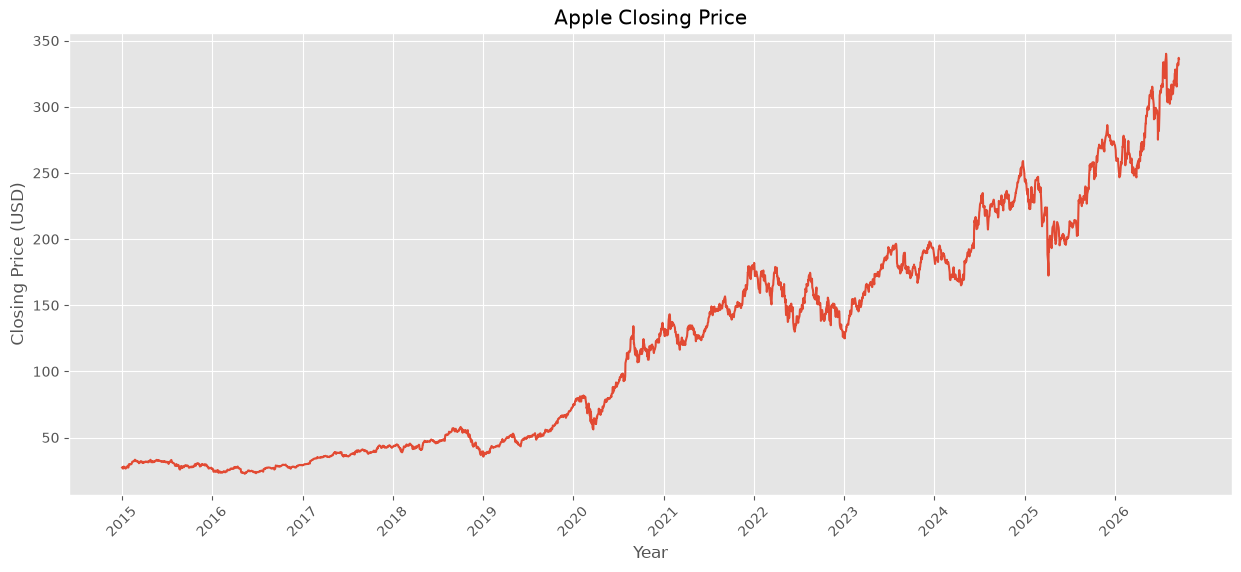

In [18]:
plt.figure(figsize=(15,6))

sns.lineplot(
    x="Date",
    y="Close",
    data=apple
)

plt.title("Apple Closing Price")

plt.xlabel("Year")

years = apple["Date"].dt.year.unique()

plt.xticks(
    pd.to_datetime(years.astype(str) + "-01-01"),
    years,
    rotation=45
)

plt.ylabel("Closing Price (USD)")

plt.show()

### Observation

Apple's closing price shows a strong upward trend over the years with noticeable declines during major market corrections, followed by significant recovery.

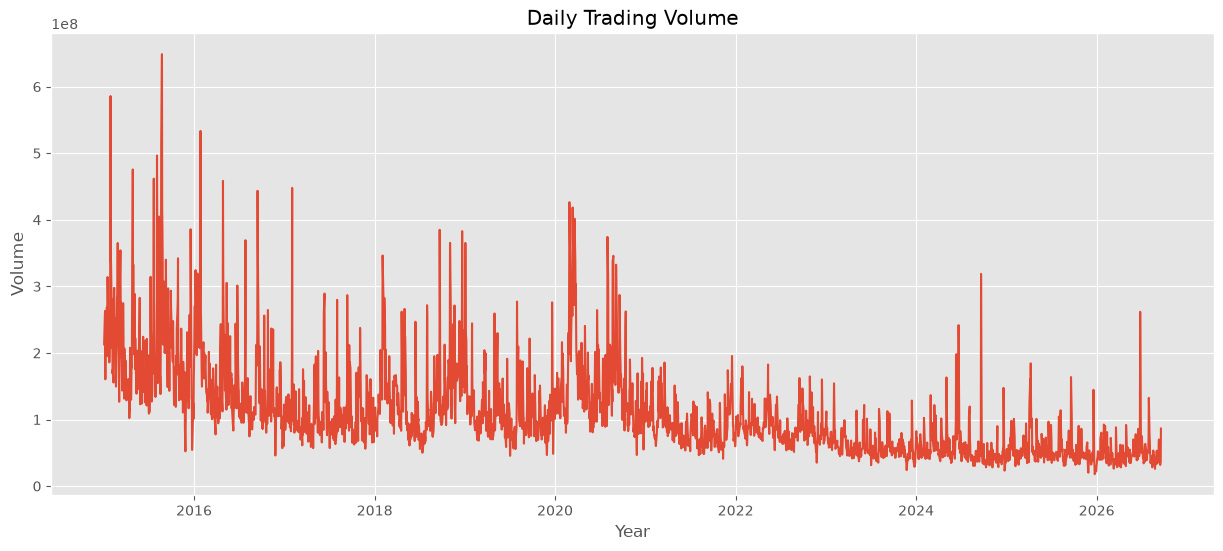

In [19]:
plt.figure(figsize=(15,6))

sns.lineplot(
    x="Date",
    y="Volume",
    data=apple
)

plt.title("Daily Trading Volume")

plt.xlabel("Year")

plt.ylabel("Volume")

plt.show()

### Observation

Trading volume spikes indicate periods of increased investor activity, often corresponding to important market events.

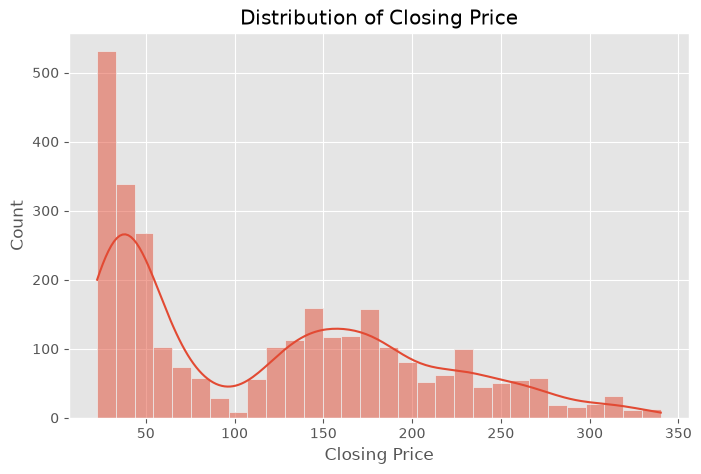

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    apple["Close"],
    bins=30,
    kde=True
)

plt.title("Distribution of Closing Price")

plt.xlabel("Closing Price")

plt.show()

### Observation

The distribution is positively skewed because Apple's stock price increased substantially over the selected time period.

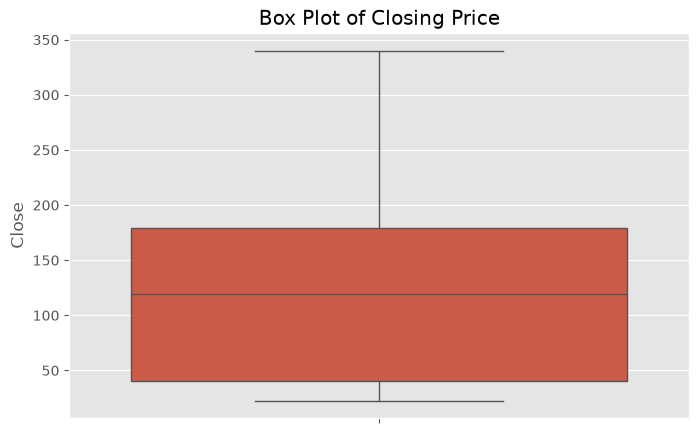

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=apple["Close"]
)

plt.title("Box Plot of Closing Price")

plt.show()

In [22]:
Q0 = apple["Close"].min()
Q1 = apple["Close"].quantile(0.25)
Q2 = apple["Close"].median()          # or quantile(0.50)
Q3 = apple["Close"].quantile(0.75)
Q4 = apple["Close"].max()

IQR = Q3 - Q1

print(f"Q0 (Minimum): {Q0:.2f}")
print(f"Q1 (25th Percentile): {Q1:.2f}")
print(f"Q2 (Median): {Q2:.2f}")
print(f"Q3 (75th Percentile): {Q3:.2f}")
print(f"Q4 (Maximum): {Q4:.2f}")
print(f"IQR: {IQR:.2f}")

Q0 (Minimum): 22.58
Q1 (25th Percentile): 40.40
Q2 (Median): 119.39
Q3 (75th Percentile): 179.29
Q4 (Maximum): 340.08
IQR: 138.89


### Observation

The box plot shows several high-value observations. These represent genuine market growth rather than data errors.

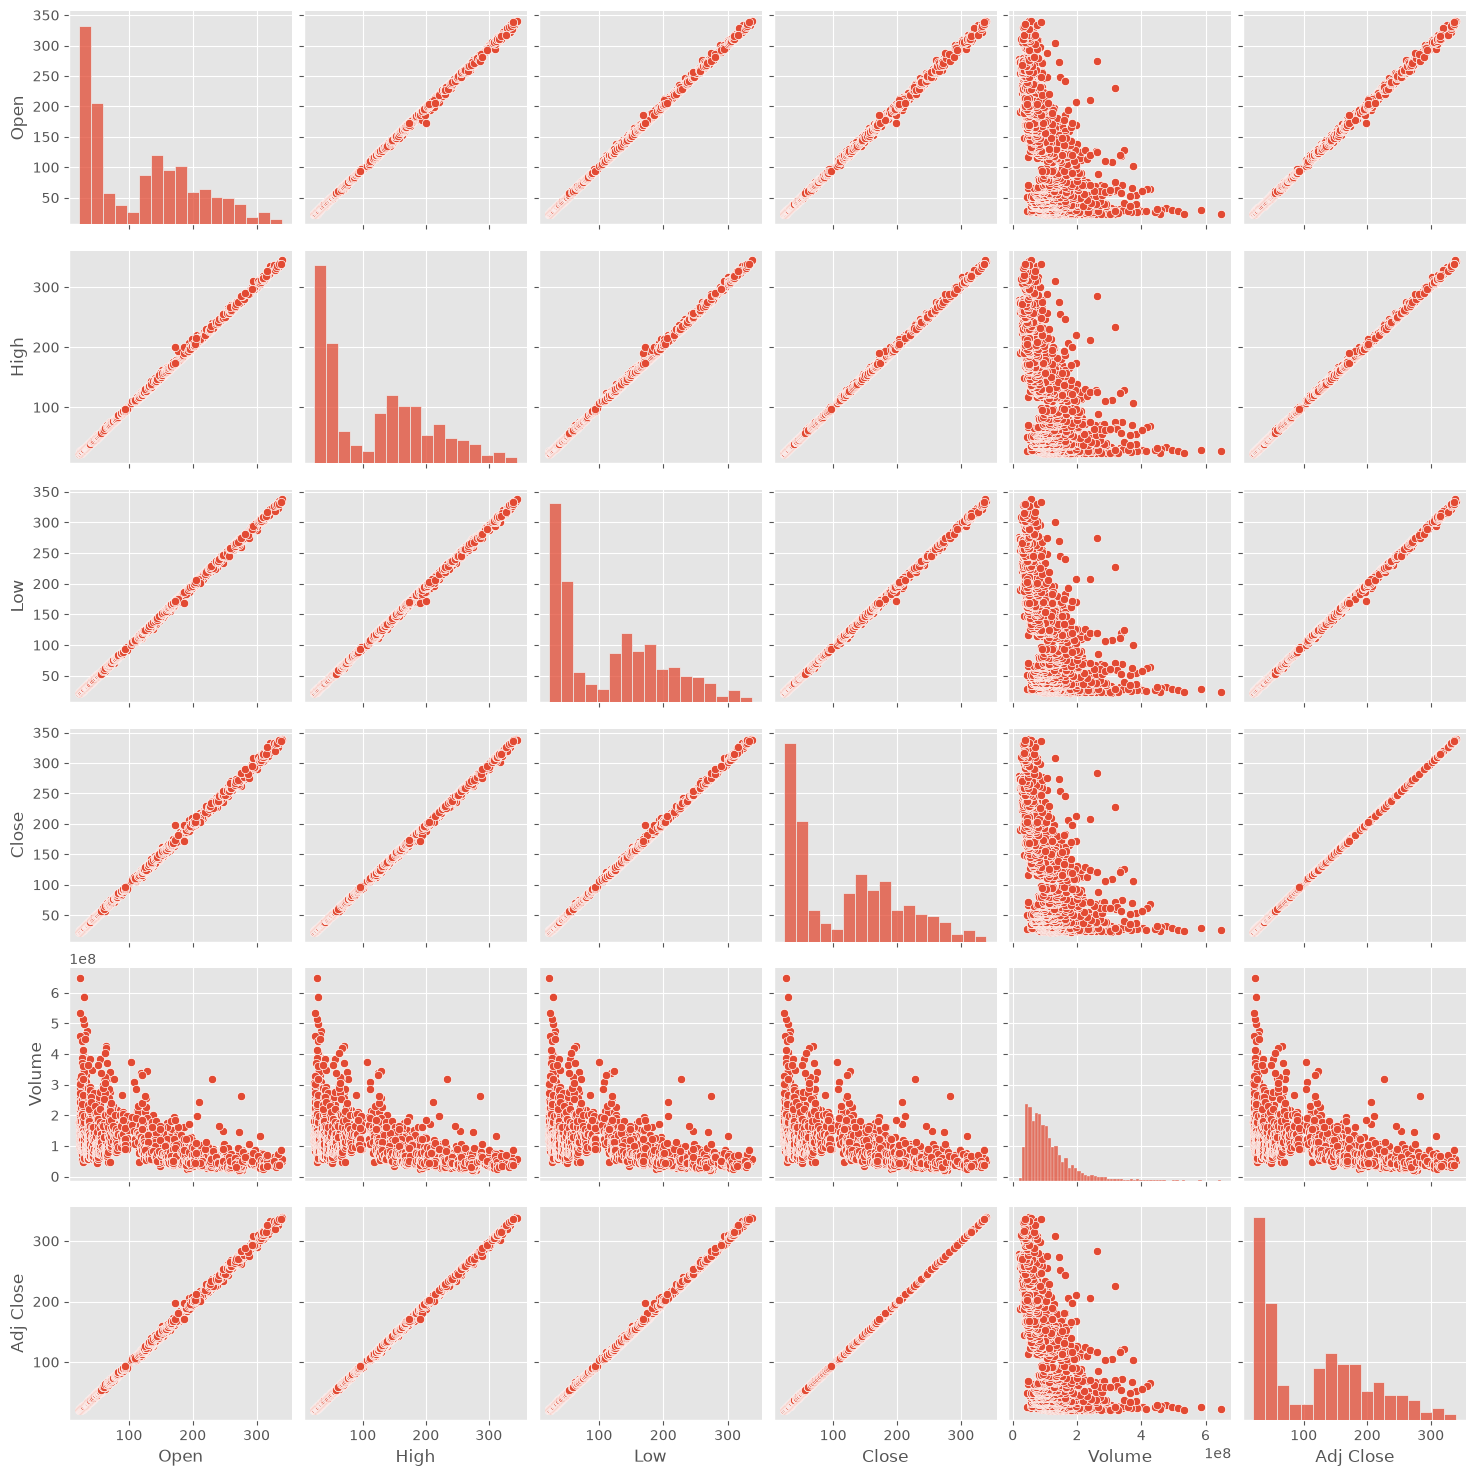

In [23]:
sns.pairplot(
    apple[
        ["Open","High","Low","Close","Volume", "Adj Close"]
    ]
)

plt.show()

### Pair Plot Analysis

- The pair plot shows the relationships among Open, High, Low, Close, Adjusted Close, and Volume.
- Open, High, Low, Close, and Adjusted Close exhibit very strong positive relationships because they represent closely related stock price measures.
- The distributions on the diagonal show the individual distributions of the numerical variables.
- Trading Volume shows a highly right-skewed distribution, with a relatively small number of days having substantially higher trading activity.
- Volume shows a comparatively weaker relationship with the price-related variables.
- Overall, the pair plot indicates strong relationships among the price-related variables, while trading volume behaves differently from the price variables.

## Conclusion

The exploratory analysis provides an overview of Apple's historical stock price behavior, trading volume, distributions, outliers, and relationships among numerical variables.

The analysis of Open, High, Low, Close, and Adjusted Close shows strong relationships among the price-related variables, while Volume exhibits a different distribution and comparatively weaker relationships with price.

These observations provide a foundation for the subsequent feature engineering and machine learning stages of StockVision.

The dataset is continuously updated with newly available market data, allowing subsequent stages to work with more recent information.